In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker
from src.utils.plotting import plot_markov_matrix

In [ ]:
env = EnvConfig()
fleet_data = load_and_cache_entire_fleet(env)


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 50.0 kW
 -> Grid Dimensions    : N_d=21, N_n=5, N_soc=73, N_fc=65, N_bat=41
 -> Augmented Space |S|: 498,225 states
 -> Action Space |A|   : 205 actions
 -> Est. Big-O Comput. : O(33,779,655,000) operations
 -> Est. RAM Footprint : ~2860.37 MB

Loading fleet data from binary cache: c:\Users\ext-adam\Desktop\INTERNSHIP\Mariner\opt_power\data\cache\fleet_data_cache.npz
 -> Cache instantly loaded in 0.079 seconds.


 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


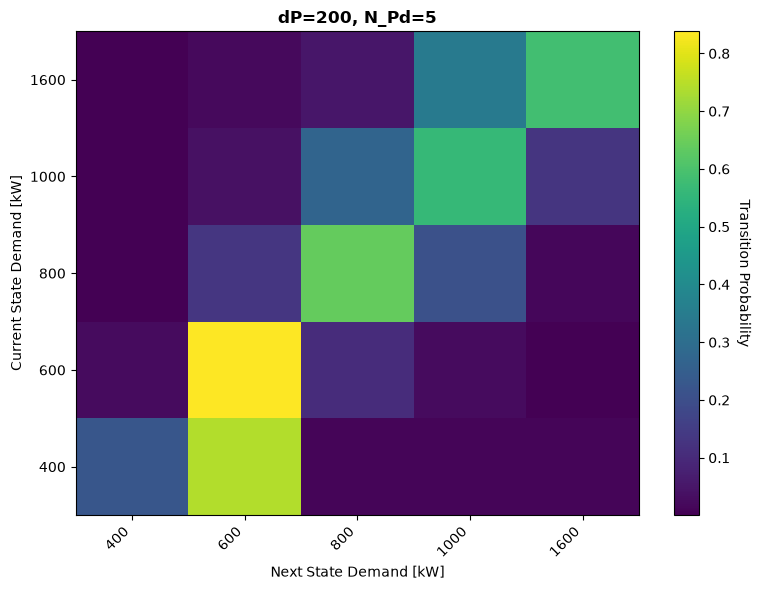

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


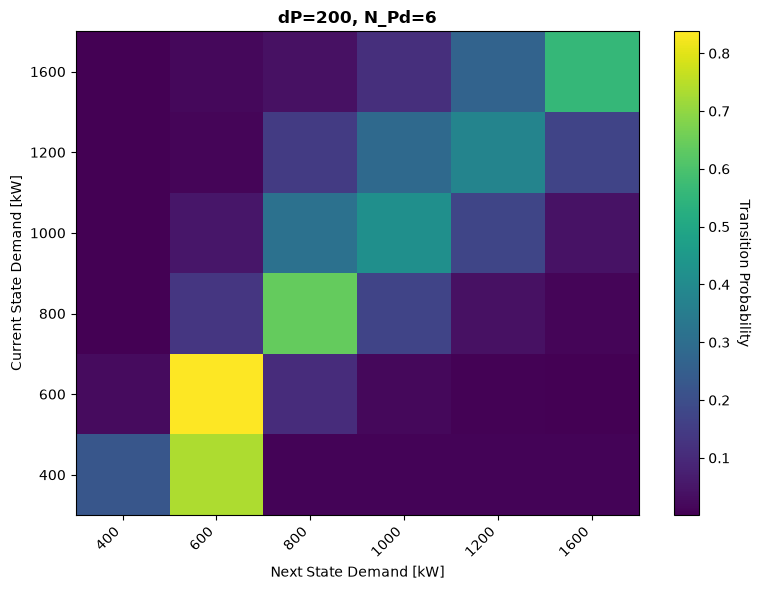

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


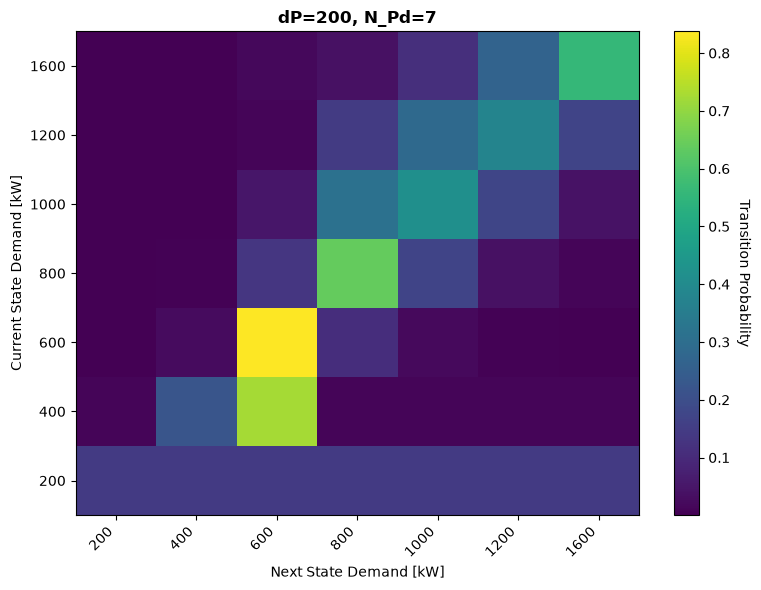

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


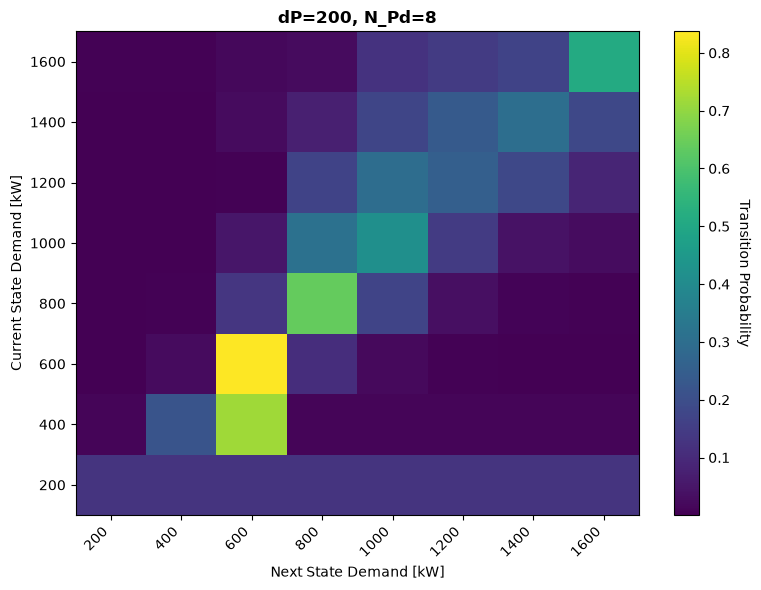

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


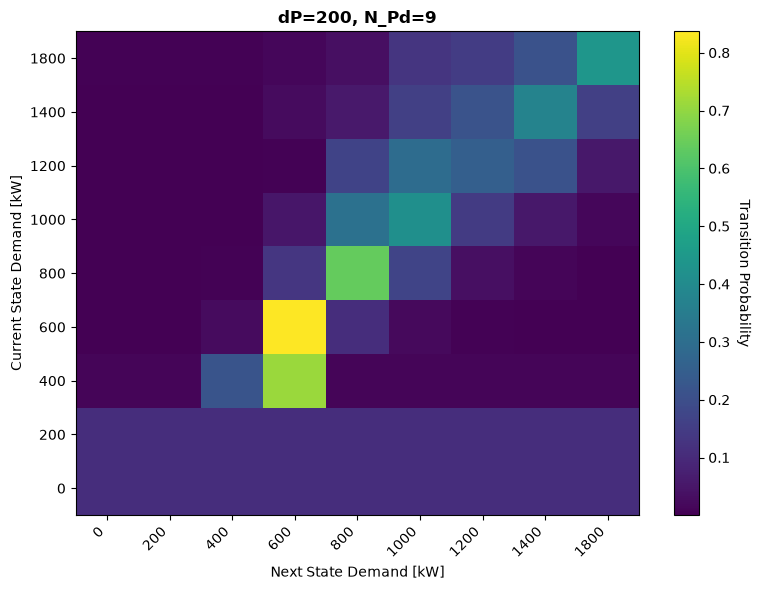

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


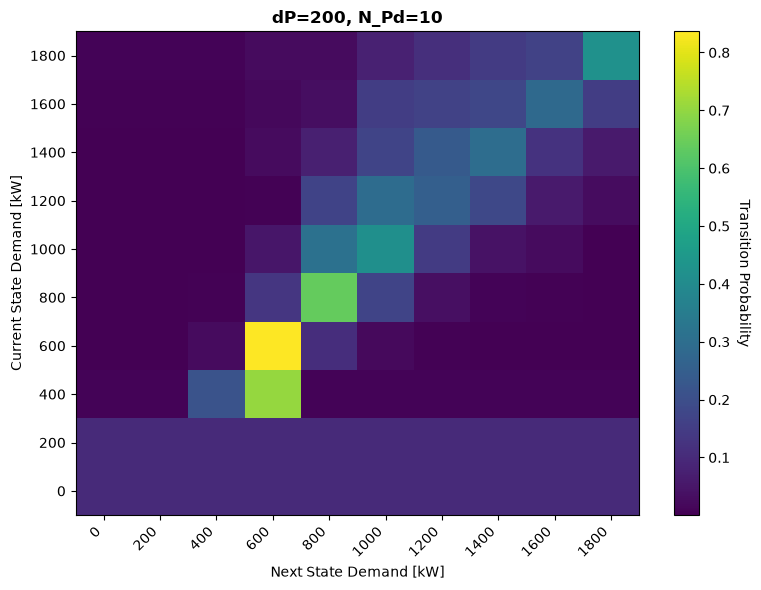

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


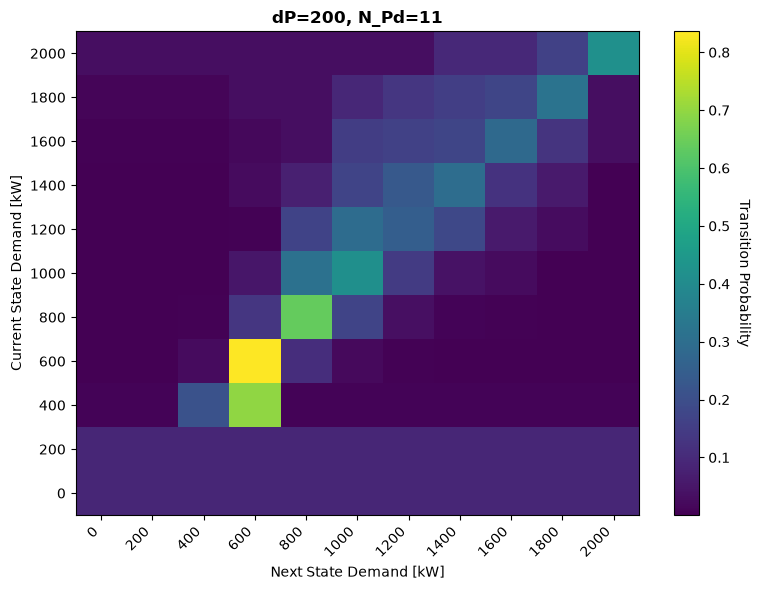

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


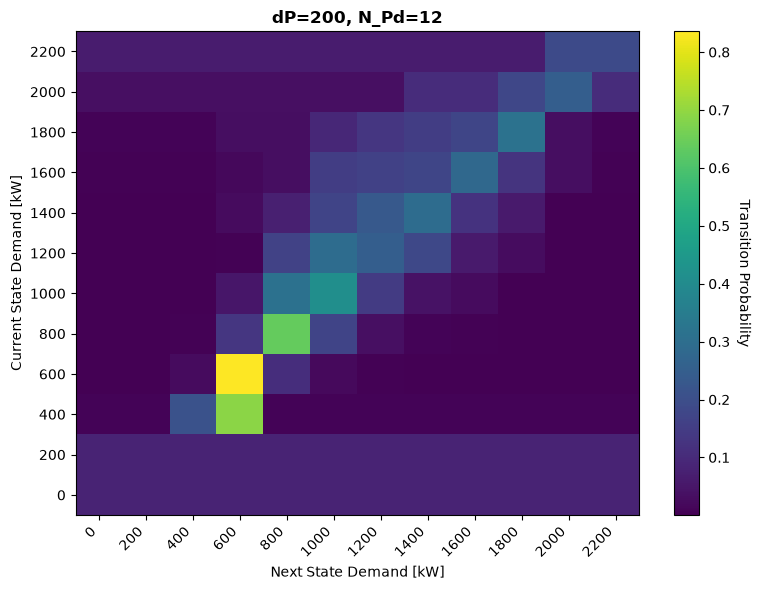

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


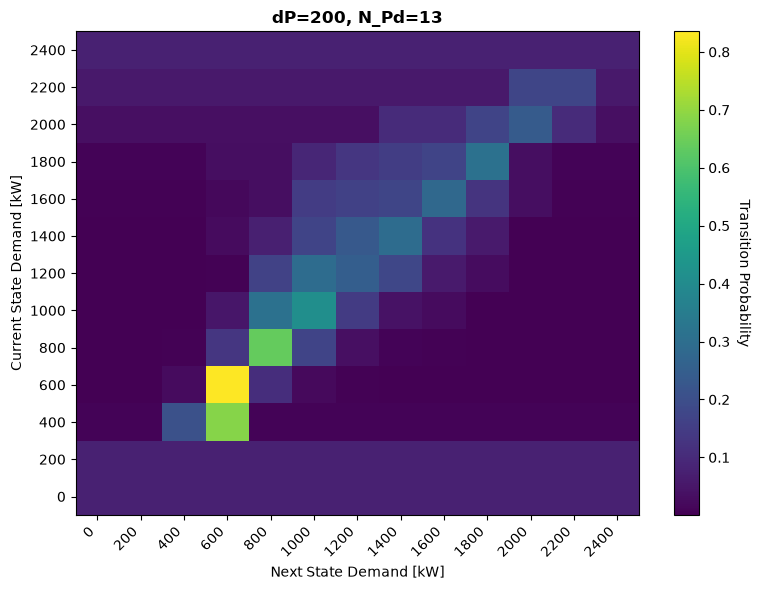

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


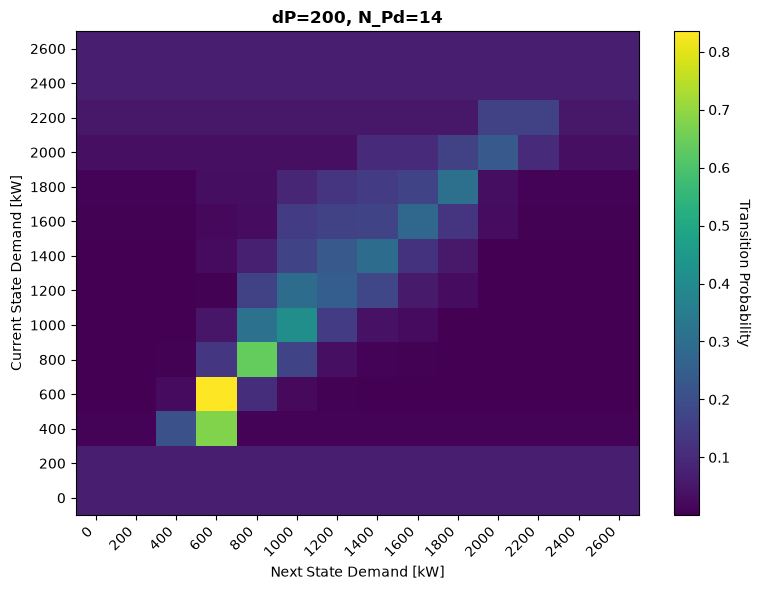

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


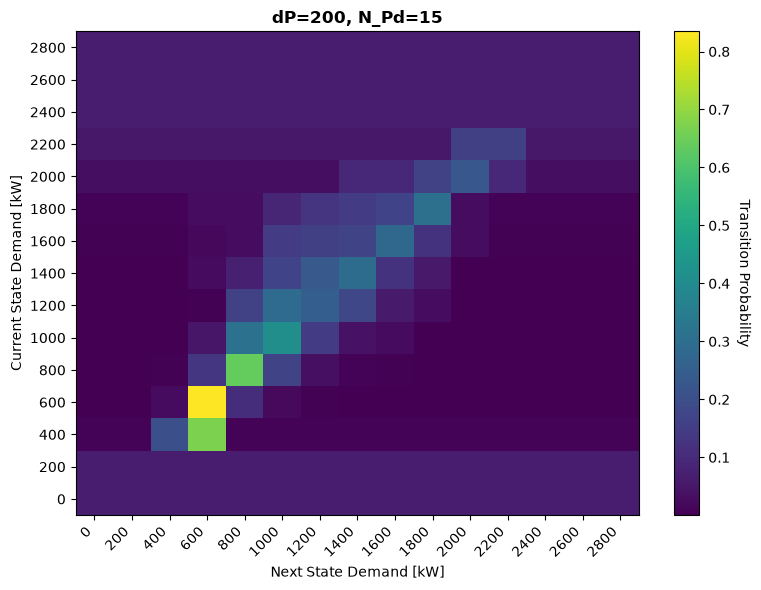

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


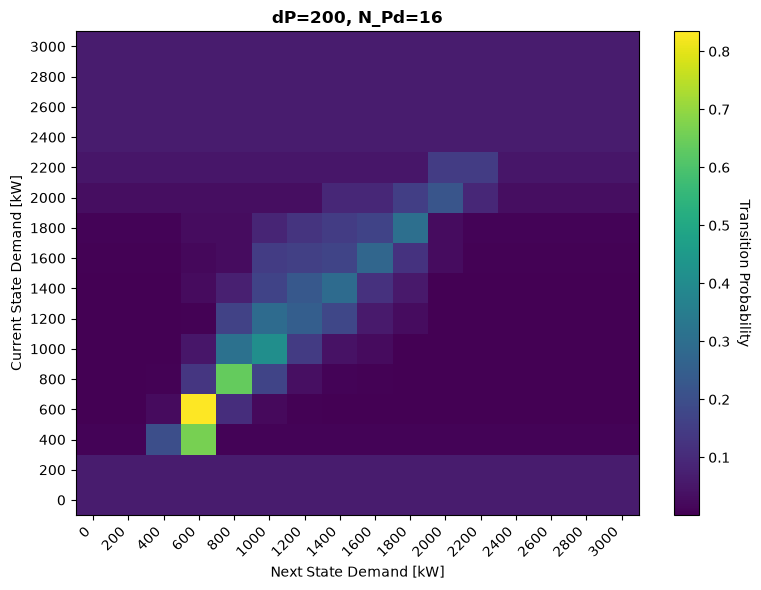

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


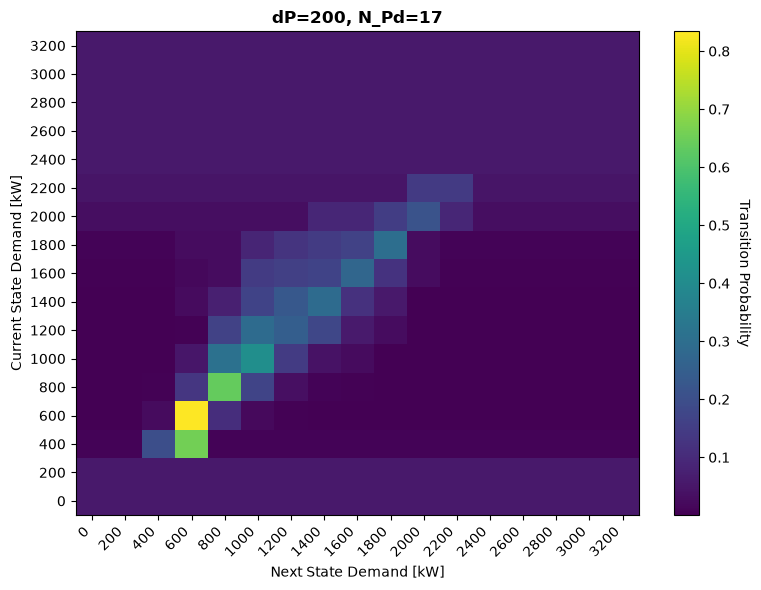

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


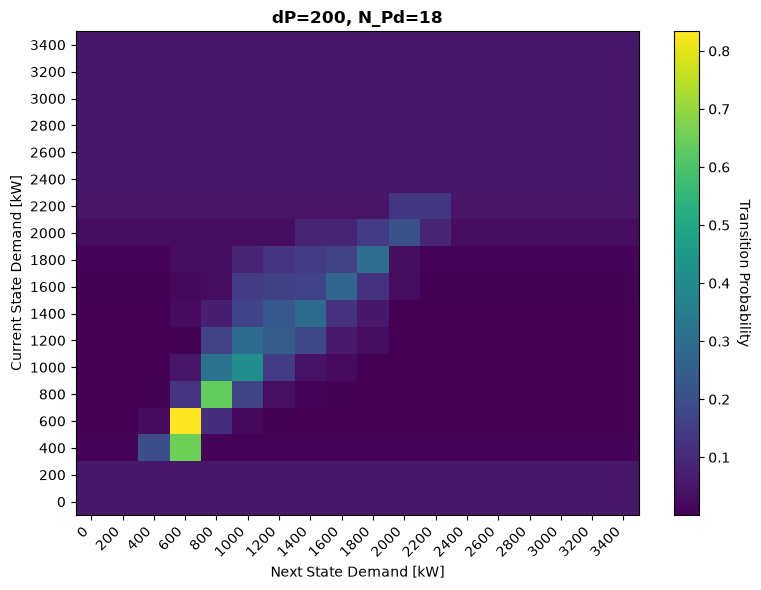

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


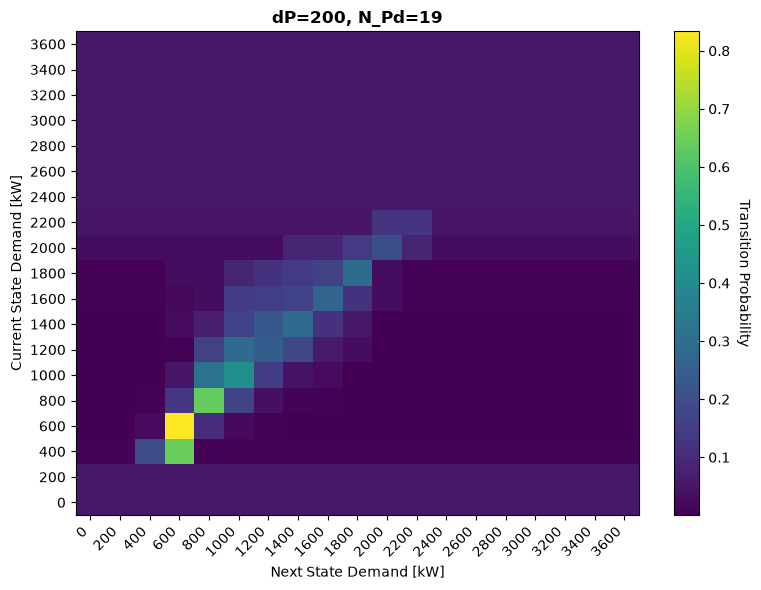

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


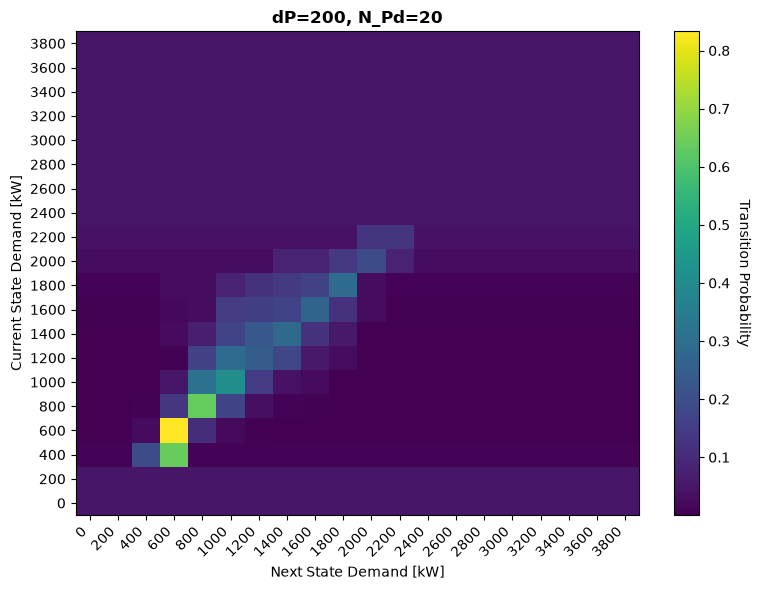

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


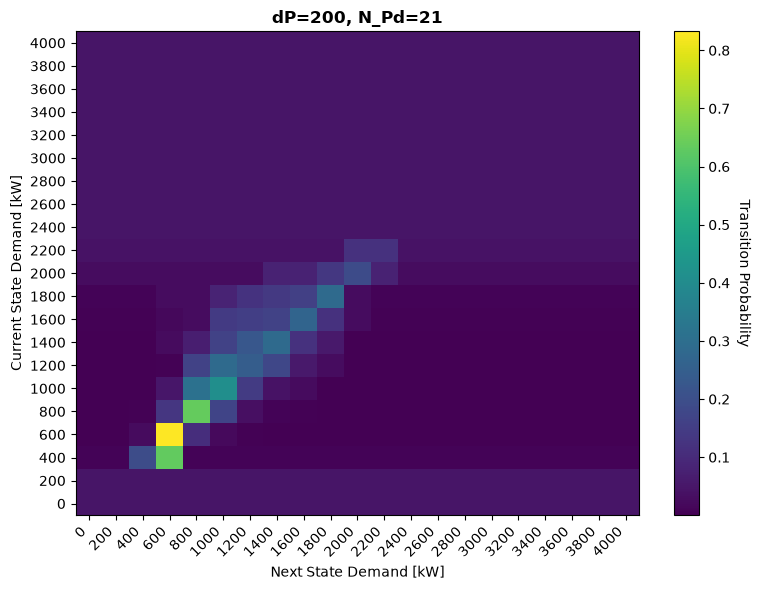

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


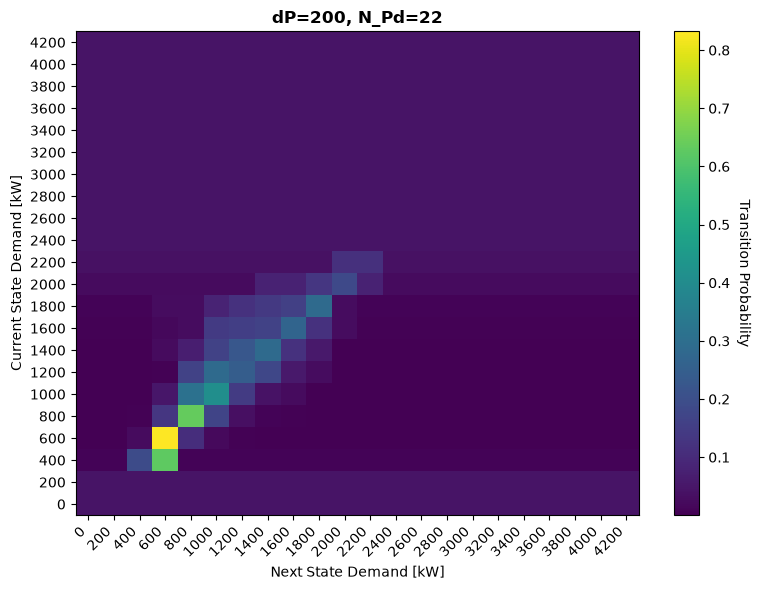

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


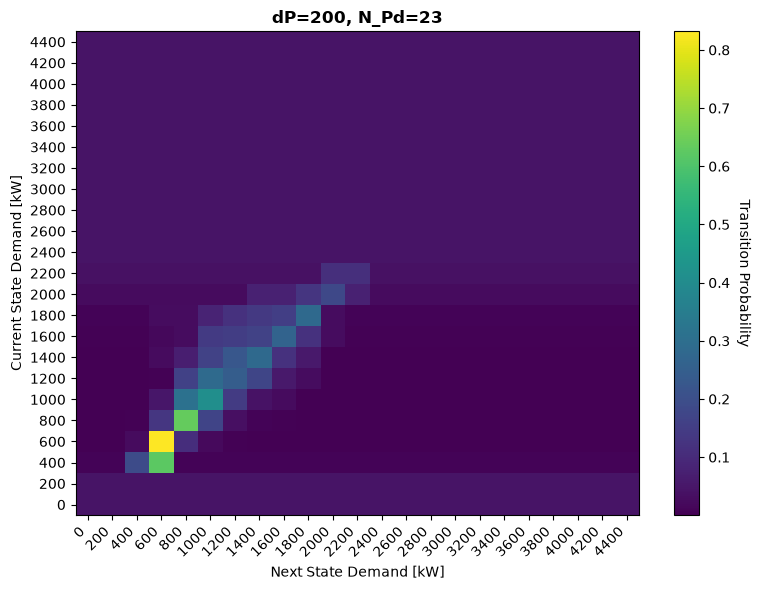

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


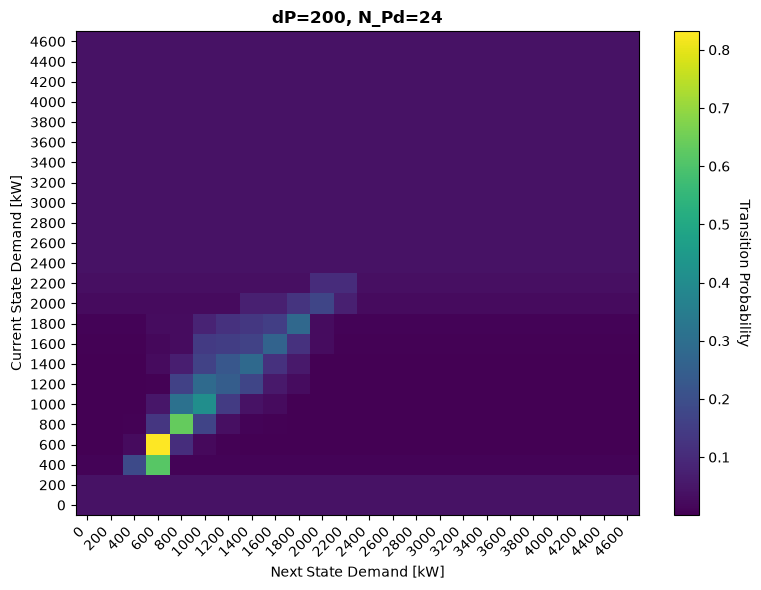

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


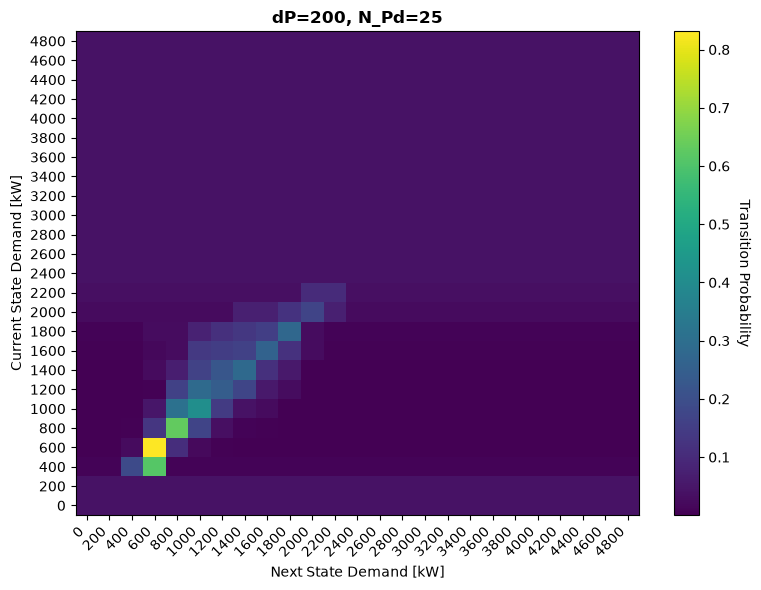

In [10]:
exclude_days = [1,2,3]
train_days = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
dP = 200
for i in range(5, 26):
    config = SimConfig(dP=dP, N_Pd=i, verbose=False)
    benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)
    mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
    plot_markov_matrix(mc_model, title=f"dP={dP}, N_Pd={i}")
